# RCCO behavior cloning flow

Trains and verifies one RCCO-based behavior cloning controller (AL5D) from a demopack. The controller is an encoder chosen by `sp_type` (a proprioception-tuned ResNet-50 or VGG19 CNN, a Conv-VAE-Neo, or a VAE-GAN), followed by the controller chosen by `controller_type`: an MLP, or an LSTM (plain or residual) with an MLP or MDN head (see `CONTROLLER_TYPES` in robot_controller/rcco_flow.py). The flow generates the exp/runs for

1. training the sensor processing whose encoder the controller uses,
2. training the controller, starting from that encoder (Train_RCCO),
3. verifying the exported controller with teacher forcing on held-out demonstrations (Verify_RCCO),

and runs them with papermill. To compare controllers built on several encoders, use Flow_RCCO_Compare. See robot_controller/DESIGN-BehaviorCloningFlow.md and data/expruns/DESIGN-Flows.md.

In [1]:
import sys
sys.path.append("..")
from exp_run_config import Config
Config.PROJECTNAME = "BerryPicker"

import pathlib
from flow import setup_flow, run_flow, display_flow_report
from demonstration.demopack import import_demopack, group_chooser_sp_bc_standard
from robot_controller.rcco_flow import (
    flow_families, generate_sp_stage, generate_controller_stages,
    generate_compare)

In [2]:
flow_name = "RCCO-BC-automove"
demopack_name = "automove-pack-01"
demonstration_cam = "dev2"
# touch-apple has rc-position-targets outside the AL5D limits, which the
# position conversion rejects (see DESIGN-BehaviorCloningFlow.md)
# flow_name = "RCCO-BC-touch-apple"
# demopack_name = "touch-apple"
# demonstration_cam = "dev0"

# The encoder of the controller: resnet50, vgg19, vae, or vae_gan
sp_type = "resnet50"
# What follows the encoder: mlp, lstm_mlp, lstm_residual_mlp, or lstm_residual_mdn
controller_type = "lstm_mlp"

# The number of epochs used for training.
# -- low values for debugging the flow
# epochs_sp = 2
# epochs_warmup = 1
# epochs_end_to_end = 1
epochs_sp = 100
epochs_warmup = 20
epochs_end_to_end = 20

# Reuse each producer directory, creating it only when absent.
creation_style = "exist-ok"
# Move each existing producer directory to a timestamped backup, then start fresh.
# creation_style = "version"
# Delete each existing producer directory, then start fresh.
# creation_style = "discard-old"

## Set up the flow directory and import the demonstrations

In [3]:
expruns_path, results_path, notebooks_path = setup_flow(
    flow_name, flow_families([sp_type]))

demopack_path = pathlib.Path(Config()["demopacks_path"], demopack_name).expanduser()
selection = import_demopack(demopack_path, group_chooser_sp_bc_standard)
data = {group: [[demopack_name, demo, demonstration_cam] for demo in selection[group]]
        for group in ["sp_training", "sp_validation", "bc_training",
                      "bc_validation", "bc_testing"]}
for group, entries in data.items():
    print(f"{group}: {[entry[1] for entry in entries]}")

***ExpRun**: Loading pointer config file:
	/home/lotzicoderone/.config/BerryPicker/mainsettings.yaml
***ExpRun**: Loading machine-specific config file:
	/home/lotzicoderone/Documents/GitHub/Lotzi-BerryPicker-Settings/settings/settings-glassy-lotzicoderone.yaml
***ExpRun**: Using torch device: cuda
***ExpRun**: Experiment config path changed to /home/lotzicoderone/WORK/BerryPicker-Flows/RCCO-BC-automove/expruns
***ExpRun**: Experiment data path changed to /home/lotzicoderone/WORK/BerryPicker-Flows/RCCO-BC-automove/results
*** import_demopack: /home/lotzicoderone/WORK/BerryPicker-Demopacks/automove-pack-01, target directory /home/lotzicoderone/WORK/BerryPicker-Flows/RCCO-BC-automove/results/demonstration/automove-pack-01 already exists, not copying
sp_training: ['sp_training_00000', 'sp_training_00001', 'sp_training_00002', 'sp_training_00003']
sp_validation: ['sp_validation_00000', 'sp_validation_00001']
bc_training: ['bc_training_00000', 'bc_training_00001', 'bc_training_00002', 'bc_tr

## Generate the exp/runs
The generators in robot_controller/rcco_flow.py write the exp/runs of the controller into the flow's exprun directory, starting from the sample exp/runs, and return the flow entries that run them.

In [4]:
entries = [generate_sp_stage(sp_type, data, epochs_sp, creation_style)]
entries += generate_controller_stages(
    sp_type, controller_type, data, epochs_warmup, epochs_end_to_end,
    creation_style)
for entry in entries:
    print(entry["name"], entry["notebook"])

***ExpRun**: Configuration for exp/run: sensorprocessing_propriotuned_cnn/_flow_sp_resnet50 successfully loaded
***ExpRun**: Configuration for exp/run: robot_controller_training/_flow_trec_resnet50_lstm_mlp successfully loaded
***ExpRun**: Configuration for exp/run: robot_controller_verify/_flow_verify_resnet50_lstm_mlp successfully loaded
TrainSP _flow_sp_resnet50 sensorprocessing/Train_ProprioTuned_CNN.ipynb
TrainRCCO _flow_trec_resnet50_lstm_mlp robot_controller/Train_RCCO.ipynb
VerifyRCCO _flow_verify_resnet50_lstm_mlp robot_controller/Verify_RCCO.ipynb


## Run the flow
Run the notebooks with papermill. To follow the execution inside a notebook, open its executed notebook through the link printed before each stage. A failing notebook stops the flow; the final cell reports which stages completed and re-raises the error.

In [5]:
flow_error = None
try:
    run_flow(entries, expruns_path, results_path, notebooks_path)
except Exception as error:
    flow_error = error

Overall flow:   0%|          | 0/3 [00:00<?, ?notebook/s, 3 notebooks left; current: TrainSP _flow_sp_resnet50]

Executing:   0%|          | 0/11 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.
Overall flow:  33%|███▎      | 1/3 [00:02<00:05,  2.61s/notebook, 2 notebooks left; current: TrainRCCO _flow_trec_resnet50_lstm_mlp]

/home/lotzicoderone/WORK/BerryPicker/vm/berrypickervenv/lib/python3.12/site-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)


Executing:   0%|          | 0/10 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.
Overall flow:  67%|██████▋   | 2/3 [00:05<00:02,  2.88s/notebook, 1 notebook left; current: VerifyRCCO _flow_verify_resnet50_lstm_mlp]

Executing:   0%|          | 0/14 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.
Overall flow: 100%|██████████| 3/3 [00:14<00:00,  4.77s/notebook, 0 notebooks left]                                                   


Stage,Status,Duration,Executed notebook,Results
TrainSP _flow_sp_resnet50,complete,3 s,Train_ProprioTuned_CNN_sensorprocessing_propriotuned_cnn__flow_sp_resnet50.ipynb,results
TrainRCCO _flow_trec_resnet50_lstm_mlp,complete,3 s,Train_RCCO_robot_controller_training__flow_trec_resnet50_lstm_mlp.ipynb,results
VerifyRCCO _flow_verify_resnet50_lstm_mlp,complete,9 s,Verify_RCCO_robot_controller_verify__flow_verify_resnet50_lstm_mlp.ipynb,results


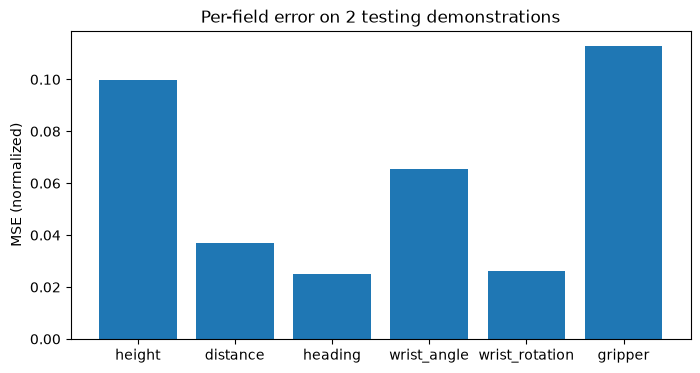

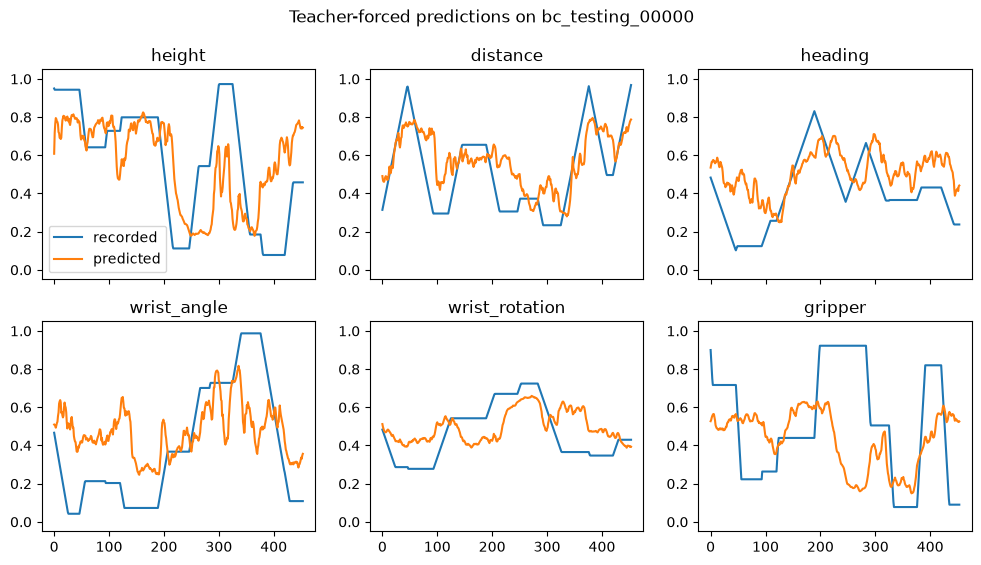

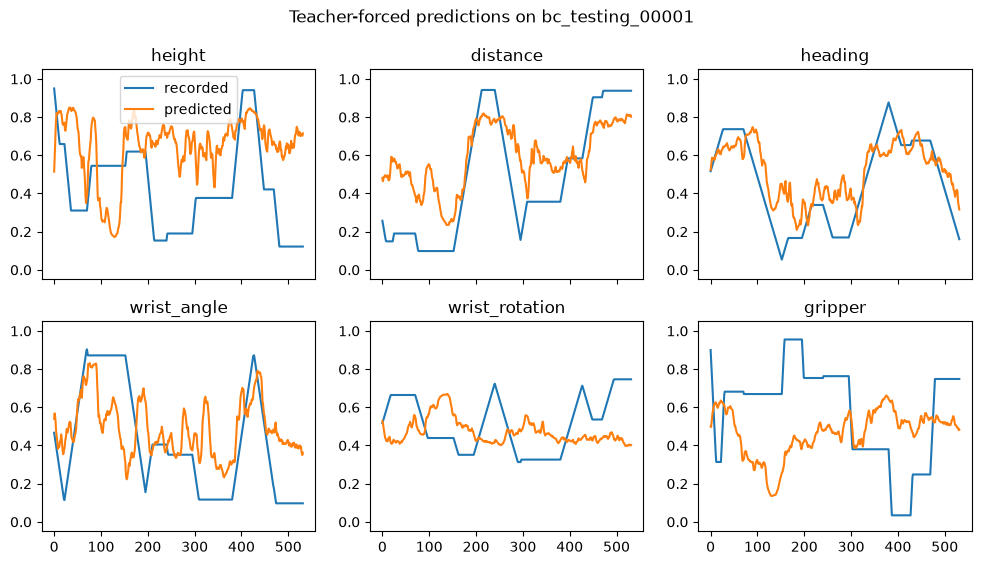

In [6]:
final_results_path = pathlib.Path(results_path, "robot_controller_verify", f"_flow_verify_{sp_type}_{controller_type}")
report = display_flow_report(
    entries, results_path, notebooks_path, final_results_path,
    flow_error=flow_error,
    preview_files=sorted(final_results_path.glob("*.png")))
if flow_error is not None:
    raise flow_error
if not report["all-results-present"]:
    raise Exception("Flow finished without all expected stage results.")